# Modelling — Autoencoder Anomaly Detection

Notebook ini melatih autoencoder untuk mendeteksi transaksi anomali.
Data diambil langsung dari hasil preprocessing (`training_data_autoencoder.csv`).

**Fitur input (scaled):**
| Fitur | Keterangan |
|---|---|
| `persona_encoded_scaled` | Tightwad=0 · Unconflicted=1 · Spendthrift=2 |
| `kategori_encoded_scaled` | Belanja=0 · F&B=1 · Groceries=2 · Hiburan=3 · Investasi=4 · Kesehatan=5 · NLP=6 · Produktivitas=7 · Tagihan=8 · Transportasi=9 |
| `savings_rate_scaled` | Rasio tabungan bulan ini |
| `night_owl_spending_scaled` | Rasio transaksi malam user bulan ini |
| `survival_mode_days_scaled` | Hari dengan saldo < 15% gaji |
| `is_night_owl_scaled` | Transaksi terjadi jam 22:00–04:00 |
| `nominal_scaled` | Nilai nominal transaksi (per segmen+kategori_detail) |

**Output per transaksi:** `s_anomali` · `ratio` · `top_features`

## 1. Import Libraries

In [120]:
import os

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.regularizers import l2

import warnings

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

print(tf.config.list_physical_devices())
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {tf.keras.__version__}")

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
TensorFlow : 2.21.0
Keras      : 3.14.1


## 2. Load Data & Metadata Preprocessing

In [121]:
DATA_DIRECTORY  = '/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/data'
MODEL_DIRECTORY = '/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/model'

dataframe_training = pd.read_csv(f'{DATA_DIRECTORY}/training_data_autoencoder.csv')
preprocessing_meta = joblib.load(f'{MODEL_DIRECTORY}/scaler_per_segment.pkl')

FEATURE_COLUMNS              = preprocessing_meta['feature_columns']
SCALED_FEATURE_COLUMNS       = preprocessing_meta['scaled_feature_columns']
SCALER_PER_SEGMENT           = preprocessing_meta['scaler_per_segment']
SCALER_NOMINAL_PER_SEG_KAT   = preprocessing_meta['scaler_nominal_per_seg_kat']
PERSONA_ENCODING_MAP         = preprocessing_meta['persona_encoding_map']
KATEGORI_ENCODING_MAP        = preprocessing_meta['kategori_encoding_map']
KATEGORI_DECODING_MAP        = {v: k for k, v in KATEGORI_ENCODING_MAP.items()}

print(f'Dataset : {dataframe_training.shape}')
print(f'Fitur   : {SCALED_FEATURE_COLUMNS}')
print()
print('Distribusi label anomali:')
print(dataframe_training['label_anomali'].value_counts())
dataframe_training.head(3)

Dataset : (50730, 20)
Fitur   : ['persona_encoded_scaled', 'kategori_encoded_scaled', 'savings_rate_scaled', 'night_owl_spending_scaled', 'survival_mode_days_scaled', 'is_night_owl_scaled', 'nominal_scaled']

Distribusi label anomali:
label_anomali
0    48957
1     1773
Name: count, dtype: int64


,id_transaksi,id_user,bulan,segmen_demografi,kategori_detail,persona_encoded,kategori_encoded,savings_rate,night_owl_spending,survival_mode_days,is_night_owl,nominal,persona_encoded_scaled,kategori_encoded_scaled,savings_rate_scaled,night_owl_spending_scaled,survival_mode_days_scaled,is_night_owl_scaled,nominal_scaled,label_anomali
0,TRX-10140,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,186000.00,1.144319,-0.569232,-0.058902,1.021899,-0.431078,-0.250459,0.791191,0
1,TRX-10141,USR-001,1,Mahasiswa,Kesehatan & Perawatan Diri,2,5,0.001871,0.111111,4,0,150000.00,1.144319,0.117255,-0.058902,1.021899,-0.431078,-0.250459,-0.079818,0
2,TRX-11790,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,112017.17,1.144319,-0.569232,-0.058902,1.021899,-0.431078,-0.250459,-0.412413,0


## 3. Persiapan Data Training

In [122]:
normal_mask = dataframe_training['label_anomali'] == 0

X_normal_data = dataframe_training.loc[normal_mask, SCALED_FEATURE_COLUMNS].values.astype(np.float32)
X_all_data    = dataframe_training[SCALED_FEATURE_COLUMNS].values.astype(np.float32)

INPUT_DIMENSION = X_all_data.shape[1]

print(f'Dimensi input            : {INPUT_DIMENSION}')
print(f'Training samples (normal): {len(X_normal_data):,}')
print(f'Total samples            : {len(X_all_data):,}')

Dimensi input            : 7
Training samples (normal): 48,957
Total samples            : 50,730


## 4. Dense Autoencoder — Arsitektur

```
Input(7) → Dense(32) → Dropout → Dense(16) → Dropout → Dense(4) [bottleneck]
         → Dense(16) → Dropout → Dense(32) → Dropout → Dense(7) [rekonstruksi]
```

In [ ]:
def build_autoencoder_model(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    
    x = Dense(32, activation="relu", kernel_regularizer=l2(1e-4))(inputs)
    x       = Dropout(0.3)(x)               
    encoded = Dense(4, activation="relu")(x) 
    
    x       = Dense(32, activation="relu")(encoded)
    decoded = Dense(input_dim, activation="linear")(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=decoded)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  
        loss="mae"
    )
    return model

autoencoder_model = build_autoencoder_model(INPUT_DIMENSION)
autoencoder_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395 (1.54 KB)

 Trainable params: 395 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Dense Autoencoder — Training

In [ ]:
EPOCHS     = 100
BATCH_SIZE = 128

os.makedirs(MODEL_DIRECTORY, exist_ok=True)

training_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(f'{MODEL_DIRECTORY}/autoencoder_anomaly.keras', monitor='val_loss', save_best_only=True, verbose=0),
]

training_history = autoencoder_model.fit(
    X_normal_data, X_normal_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    callbacks=training_callbacks,
    verbose=1
)

print(f'Epoch berhenti di : {len(training_history.history["loss"])}')
print(f'Best val_loss     : {min(training_history.history["val_loss"]):.6f}')

Epoch 1/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 1s 479us/step - loss: 0.6242 - val_loss: 0.5375 - learning_rate: 5.0000e-04
Epoch 2/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - loss: 0.5126 - val_loss: 0.4701 - learning_rate: 5.0000e-04
Epoch 3/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 0.4599 - val_loss: 0.4029 - learning_rate: 5.0000e-04
Epoch 4/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - loss: 0.4244 - val_loss: 0.3657 - learning_rate: 5.0000e-04
Epoch 5/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 0.3978 - val_loss: 0.3462 - learning_rate: 5.0000e-04
Epoch 6/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 0.3798 - val_loss: 0.3466 - learning_rate: 5.0000e-04
Epoch 7/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.3695 - val_loss: 0.3451 - learning_rate: 5.0000e-04
Epoch 8/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 0.3617 - val_loss: 0.3439 - learning_rate: 5.0000e-04
Epoch 9/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - loss: 0

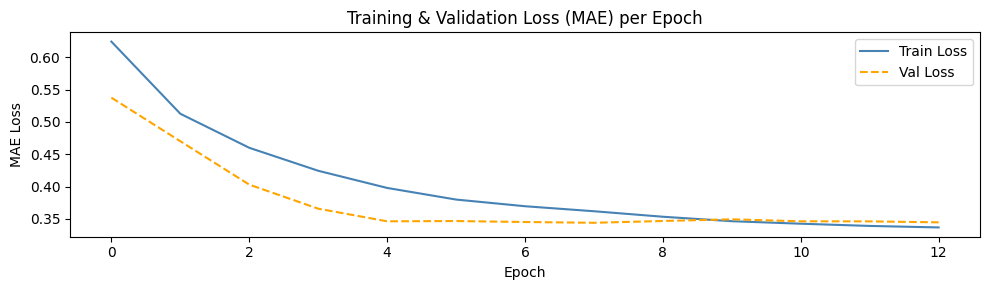

In [125]:
plt.figure(figsize=(10, 3))
plt.plot(training_history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(training_history.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
plt.title('Training & Validation Loss (MAE) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6. LSTM Autoencoder — Arsitektur

```
Input(7,1) → LSTM(32,seq) → Dropout(0.2) → LSTM(8) [bottleneck]
           → RepeatVector(7) → LSTM(8,seq) → Dropout(0.2) → LSTM(32,seq)
           → TimeDistributed(Dense(1)) [rekonstruksi]
```
Input di-reshape menjadi `(n_samples, 7, 1)` — setiap fitur sebagai timestep.

In [126]:
def build_lstm_autoencoder(input_dim):
    inputs = tf.keras.Input(shape=(input_dim, 1))

    # Encoder
    x       = tf.keras.layers.LSTM(32, return_sequences=True)(inputs)
    x       = tf.keras.layers.Dropout(0.2)(x)
    encoded = tf.keras.layers.LSTM(8, return_sequences=False)(x)

    # Decoder
    x       = tf.keras.layers.RepeatVector(input_dim)(encoded)
    x       = tf.keras.layers.LSTM(8, return_sequences=True)(x)
    x       = tf.keras.layers.Dropout(0.2)(x)
    x       = tf.keras.layers.LSTM(32, return_sequences=True)(x)
    decoded = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1, activation='linear')
    )(x)

    model = tf.keras.Model(inputs=inputs, outputs=decoded)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mae',
        jit_compile=False,
    )
    return model


lstm_autoencoder_model = build_lstm_autoencoder(INPUT_DIMENSION)
lstm_autoencoder_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 7, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 7, 32)          │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 7, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 7, 8)           │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 7, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 7, 32)          │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 7, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,489 (44.88 KB)

 Trainable params: 11,489 (44.88 KB)

 Non-trainable params: 0 (0.00 B)

## 7. LSTM Autoencoder — Training

In [127]:
X_lstm_normal = X_normal_data.reshape(-1, INPUT_DIMENSION, 1)

lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(
        f'{MODEL_DIRECTORY}/lstm_autoencoder_anomaly.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    ),
]

lstm_history = lstm_autoencoder_model.fit(
    X_lstm_normal, X_lstm_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    callbacks=lstm_callbacks,
    verbose=1
)

print(f'Epoch berhenti di : {len(lstm_history.history["loss"])}')
print(f'Best val_loss     : {min(lstm_history.history["val_loss"]):.6f}')

Epoch 1/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.6322 - val_loss: 0.5938 - learning_rate: 0.0010
Epoch 2/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5836 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 3/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5551 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 4/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5203 - val_loss: 0.4901 - learning_rate: 0.0010
Epoch 5/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4968 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 6/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4522 - val_loss: 0.3888 - learning_rate: 0.0010
Epoch 7/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4068 - val_loss: 0.3460 - learning_rate: 0.0010
Epoch 8/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3669 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 9/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3181 - val_loss: 0.2556 - learning_rate: 0.0010
E

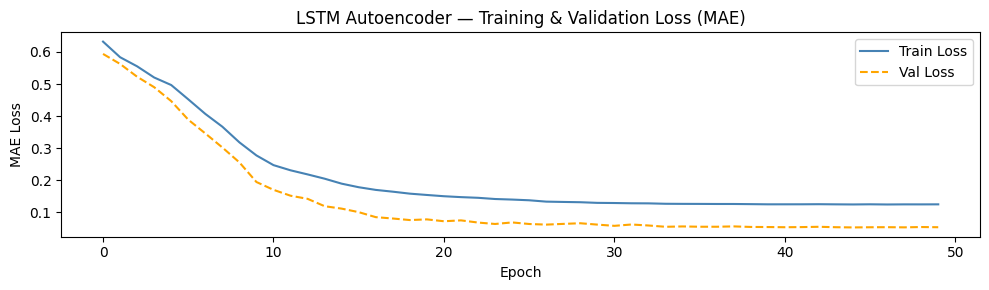

In [128]:
plt.figure(figsize=(10, 3))
plt.plot(lstm_history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(lstm_history.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
plt.title('LSTM Autoencoder — Training & Validation Loss (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 7b. Perbandingan Model — Pilih Terbaik

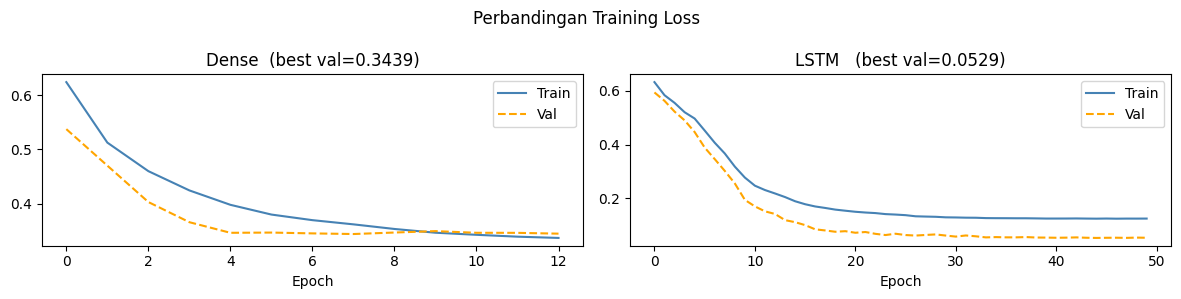

Dense Autoencoder  best val_loss : 0.343893
LSTM  Autoencoder  best val_loss : 0.052872

→ Model terbaik: LSTM Autoencoder


In [129]:
dense_best_val = min(training_history.history['val_loss'])
lstm_best_val  = min(lstm_history.history['val_loss'])

figure, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(training_history.history['loss'],     color='steelblue', label='Train')
axes[0].plot(training_history.history['val_loss'], color='orange',    label='Val', linestyle='--')
axes[0].set_title(f'Dense  (best val={dense_best_val:.4f})')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(lstm_history.history['loss'],     color='steelblue', label='Train')
axes[1].plot(lstm_history.history['val_loss'], color='orange',    label='Val', linestyle='--')
axes[1].set_title(f'LSTM   (best val={lstm_best_val:.4f})')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Perbandingan Training Loss', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Dense Autoencoder  best val_loss : {dense_best_val:.6f}')
print(f'LSTM  Autoencoder  best val_loss : {lstm_best_val:.6f}')

if dense_best_val <= lstm_best_val:
    best_model      = autoencoder_model
    best_model_name = 'dense'
else:
    best_model      = lstm_autoencoder_model
    best_model_name = 'lstm'

print(f'\n→ Model terbaik: {best_model_name.upper()} Autoencoder')

## 8. Reconstruction Error & Threshold per Kategori

- Error metric: `|actual − rekonstruksi|` per fitur (MAE-consistent)
- Threshold: Persentil 95 error normal **per kategori_detail**
- Gunakan `best_model` hasil perbandingan section 7

In [130]:
if best_model_name == 'lstm':
    X_input         = X_all_data.reshape(-1, INPUT_DIMENSION, 1)
    X_reconstructed = best_model.predict(X_input, verbose=0).reshape(-1, INPUT_DIMENSION)
else:
    X_reconstructed = best_model.predict(X_all_data, verbose=0)

per_feature_errors    = np.abs(X_all_data - X_reconstructed)
reconstruction_errors = per_feature_errors.mean(axis=1)

kategori_encoded_all    = dataframe_training['kategori_encoded'].values
THRESHOLD_PER_KATEGORI  = {}
MEAN_ERROR_PER_KATEGORI = {}

for kat_id in np.unique(kategori_encoded_all):
    kat_normal_mask = (kategori_encoded_all == kat_id) & normal_mask.values
    kat_errors      = reconstruction_errors[kat_normal_mask]
    THRESHOLD_PER_KATEGORI[int(kat_id)]  = float(np.percentile(kat_errors, 95))
    MEAN_ERROR_PER_KATEGORI[int(kat_id)] = float(kat_errors.mean())

print(f'Model digunakan : {best_model_name}')
print('Threshold & Mean Error per Kategori:')
for kat_id, threshold in THRESHOLD_PER_KATEGORI.items():
    print(f'  {KATEGORI_DECODING_MAP[kat_id]:<30}: thr={threshold:.6f}  mean={MEAN_ERROR_PER_KATEGORI[kat_id]:.6f}')

Model digunakan : lstm
Threshold & Mean Error per Kategori:
  Belanja Online & Fashion      : thr=0.126813  mean=0.057337
  F&B dan Nongkrong             : thr=0.126608  mean=0.046802
  Groceries & Kebutuhan Pokok   : thr=0.126707  mean=0.045598
  Hiburan & Langganan           : thr=0.118521  mean=0.046565
  Investasi & Finansial         : thr=0.119169  mean=0.043938
  Kesehatan & Perawatan Diri    : thr=0.119467  mean=0.043287
  NLP Classified Transfer       : thr=0.120110  mean=0.045124
  Produktivitas & Digital       : thr=0.113430  mean=0.046842
  Tagihan & Utilitas            : thr=0.129847  mean=0.050021
  Transportasi                  : thr=0.136148  mean=0.056749


## 9. Output: s_anomali · ratio · top_features

In [131]:
def get_top_contributing_features(feature_error_row, feature_names, top_count=3):
    sorted_indices = np.argsort(feature_error_row)[::-1][:top_count]
    return [feature_names[index] for index in sorted_indices]


threshold_array  = np.array([THRESHOLD_PER_KATEGORI[int(k)]  for k in kategori_encoded_all])
mean_error_array = np.array([MEAN_ERROR_PER_KATEGORI[int(k)] for k in kategori_encoded_all])

dataframe_training['s_anomali']    = reconstruction_errors > threshold_array
dataframe_training['ratio']        = np.round(reconstruction_errors / (mean_error_array + 1e-9), 2)
dataframe_training['top_features'] = [
    get_top_contributing_features(per_feature_errors[i], FEATURE_COLUMNS)
    for i in range(len(dataframe_training))
]

OUTPUT_COLUMNS = (
    ['id_transaksi', 'id_user', 'bulan', 'segmen_demografi', 'kategori_detail']
    + FEATURE_COLUMNS
    + ['s_anomali', 'ratio', 'top_features', 'label_anomali']
)

dataframe_output = dataframe_training[OUTPUT_COLUMNS].copy()

print(f'Total transaksi                   : {len(dataframe_output):,}')
print(f'Anomali terdeteksi (s_anomali)    : {dataframe_output["s_anomali"].sum():,}')
print(f'Ratio rata-rata seluruh transaksi : {dataframe_output["ratio"].mean():.2f}x')
print()
dataframe_output.head(8)

Total transaksi                   : 50,730
Anomali terdeteksi (s_anomali)    : 3,724
Ratio rata-rata seluruh transaksi : 1.54x



,id_transaksi,id_user,bulan,segmen_demografi,kategori_detail,persona_encoded,kategori_encoded,savings_rate,night_owl_spending,survival_mode_days,is_night_owl,nominal,s_anomali,ratio,top_features,label_anomali
0,TRX-10140,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,186000.00,False,0.45,"[night_owl_spending, savings_rate, persona_enc...",0
1,TRX-10141,USR-001,1,Mahasiswa,Kesehatan & Perawatan Diri,2,5,0.001871,0.111111,4,0,150000.00,False,0.56,"[night_owl_spending, kategori_encoded, savings...",0
2,TRX-11790,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,112017.17,False,0.43,"[night_owl_spending, savings_rate, nominal]",0
3,TRX-11792,USR-001,1,Mahasiswa,Belanja Online & Fashion,2,0,0.001871,0.111111,4,0,595635.11,False,1.00,"[kategori_encoded, nominal, night_owl_spending]",0
4,TRX-11794,USR-001,1,Mahasiswa,NLP Classified Transfer,2,6,0.001871,0.111111,4,0,73294.82,False,0.46,"[night_owl_spending, kategori_encoded, savings...",0
5,TRX-11791,USR-001,1,Mahasiswa,Belanja Online & Fashion,2,0,0.001871,0.111111,4,0,538679.99,False,0.85,"[kategori_encoded, night_owl_spending, nominal]",0
6,TRX-11793,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,119127.67,False,0.43,"[night_owl_spending, savings_rate, nominal]",0
7,TRX-15368,USR-001,1,Mahasiswa,Produktivitas & Digital,2,7,0.001871,0.111111,4,0,72030.00,False,0.44,"[nominal, night_owl_spending, savings_rate]",0


In [132]:
print('=== Contoh Transaksi Anomali Terdeteksi ===')
dataframe_output[dataframe_output['s_anomali']].sort_values('ratio', ascending=False).head(10)

=== Contoh Transaksi Anomali Terdeteksi ===


,id_transaksi,id_user,bulan,segmen_demografi,kategori_detail,persona_encoded,kategori_encoded,savings_rate,night_owl_spending,survival_mode_days,is_night_owl,nominal,s_anomali,ratio,top_features,label_anomali
40117,TRX-40514,USR-437,2,Profesional,Transportasi,1,9,0.041227,0.062500,12,0,4.289246e+06,True,118.78,"[nominal, persona_encoded, savings_rate]",1
29896,TRX-50709,USR-360,3,First Jobber,Transportasi,2,9,-0.000423,0.000000,2,0,3.822920e+06,True,117.64,"[nominal, savings_rate, survival_mode_days]",1
4534,TRX-17053,USR-066,1,Mahasiswa,Transportasi,0,9,1.058556,0.142857,0,0,2.638777e+06,True,111.03,"[nominal, savings_rate, survival_mode_days]",1
33614,TRX-49499,USR-398,3,First Jobber,Transportasi,2,9,0.174099,0.031250,4,0,3.368000e+06,True,105.18,"[nominal, savings_rate, survival_mode_days]",1
26985,TRX-48136,USR-330,3,First Jobber,Transportasi,1,9,-0.000288,0.000000,4,0,3.445830e+06,True,104.99,"[nominal, savings_rate, persona_encoded]",1
40291,TRX-48361,USR-438,3,Profesional,Transportasi,2,9,0.003486,0.050000,9,0,3.841288e+06,True,104.80,"[nominal, savings_rate, night_owl_spending]",1
15049,TRX-49741,USR-207,3,First Jobber,Transportasi,1,9,-0.003731,0.000000,5,0,3.389684e+06,True,102.70,"[nominal, savings_rate, persona_encoded]",1
31747,TRX-14273,USR-380,1,First Jobber,Transportasi,1,9,0.002691,0.111111,8,0,3.369399e+06,True,100.57,"[nominal, persona_encoded, savings_rate]",1
37823,TRX-16885,USR-423,1,Profesional,Transportasi,2,9,0.020976,0.044444,12,0,3.672210e+06,True,99.40,"[nominal, savings_rate, night_owl_spending]",1
25961,TRX-12638,USR-319,1,First Jobber,Transportasi,1,9,0.001592,0.037037,4,0,3.228276e+06,True,97.27,"[nominal, savings_rate, persona_encoded]",1


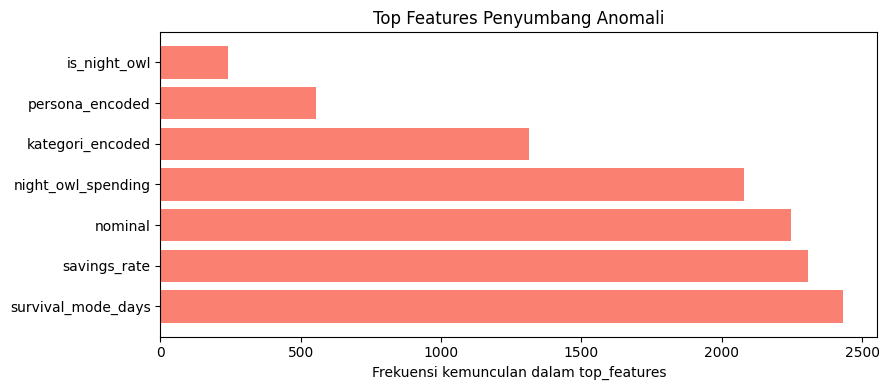

Distribusi top features pada anomali:
  survival_mode_days                 : 2432
  savings_rate                       : 2306
  nominal                            : 2248
  night_owl_spending                 : 2078
  kategori_encoded                   : 1314
  persona_encoded                    : 555
  is_night_owl                       : 239


In [133]:
anomaly_top_features = dataframe_output[dataframe_output['s_anomali']]['top_features'].explode()
feature_frequency    = Counter(anomaly_top_features)

feature_names_sorted  = [name  for name, _     in sorted(feature_frequency.items(), key=lambda x: -x[1])]
feature_counts_sorted = [count for _,    count in sorted(feature_frequency.items(), key=lambda x: -x[1])]

plt.figure(figsize=(9, 4))
plt.barh(feature_names_sorted, feature_counts_sorted, color='salmon')
plt.title('Top Features Penyumbang Anomali')
plt.xlabel('Frekuensi kemunculan dalam top_features')
plt.tight_layout()
plt.show()

print('Distribusi top features pada anomali:')
for feature_name, feature_count in zip(feature_names_sorted, feature_counts_sorted):
    print(f'  {feature_name:<35}: {feature_count}')

## 10. Evaluasi (vs Label Ground Truth)

In [134]:
ground_truth_labels  = dataframe_output['label_anomali'].astype(int)
predicted_labels     = dataframe_output['s_anomali'].astype(int)

print('=== Evaluasi Autoencoder Anomaly Detection ===')
print(f'Ground truth anomali : {ground_truth_labels.sum():,}')
print(f'Prediksi anomali     : {predicted_labels.sum():,}')
print()
print(classification_report(ground_truth_labels, predicted_labels, target_names=['Normal', 'Anomali']))

confusion_matrix_result = confusion_matrix(ground_truth_labels, predicted_labels)
print('Confusion Matrix:')
print(pd.DataFrame(
    confusion_matrix_result,
    index=['Actual Normal', 'Actual Anomali'],
    columns=['Pred Normal', 'Pred Anomali']
))

=== Evaluasi Autoencoder Anomaly Detection ===
Ground truth anomali : 1,773
Prediksi anomali     : 3,724

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     48957
     Anomali       0.34      0.72      0.46      1773

    accuracy                           0.94     50730
   macro avg       0.67      0.83      0.72     50730
weighted avg       0.97      0.94      0.95     50730

Confusion Matrix:
                Pred Normal  Pred Anomali
Actual Normal         46505          2452
Actual Anomali          501          1272


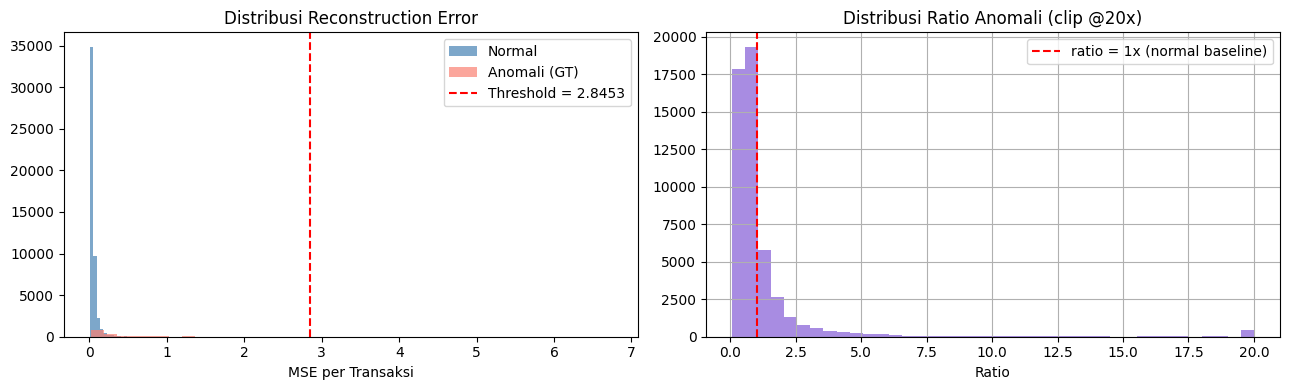

In [135]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(reconstruction_errors[normal_mask.values],  bins=40, alpha=0.7, label='Normal',      color='steelblue')
axes[0].hist(reconstruction_errors[~normal_mask.values], bins=40, alpha=0.7, label='Anomali (GT)', color='salmon')
axes[0].axvline(ANOMALY_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {ANOMALY_THRESHOLD:.4f}')
axes[0].set_title('Distribusi Reconstruction Error')
axes[0].set_xlabel('MSE per Transaksi')
axes[0].legend()

dataframe_output['ratio'].clip(upper=20).hist(bins=40, ax=axes[1], color='mediumpurple', alpha=0.8)
axes[1].axvline(1.0, color='red', linestyle='--', label='ratio = 1x (normal baseline)')
axes[1].set_title('Distribusi Ratio Anomali (clip @20x)')
axes[1].set_xlabel('Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Simpan Model & Hasil

In [136]:
joblib.dump({
    'threshold_per_kategori'     : THRESHOLD_PER_KATEGORI,
    'mean_error_per_kategori'    : MEAN_ERROR_PER_KATEGORI,
    'feature_columns'            : FEATURE_COLUMNS,
    'scaled_feature_columns'     : SCALED_FEATURE_COLUMNS,
    'scaler_per_segment'         : SCALER_PER_SEGMENT,
    'scaler_nominal_per_seg_kat' : SCALER_NOMINAL_PER_SEG_KAT,
    'persona_encoding_map'       : PERSONA_ENCODING_MAP,
    'kategori_encoding_map'      : KATEGORI_ENCODING_MAP,
    'best_model_name'            : best_model_name,
}, f'{MODEL_DIRECTORY}/anomaly_inference_meta.pkl')

dataframe_output.to_csv(f'{DATA_DIRECTORY}/anomaly_results.csv', index=False)

print(f'Dense Model → {MODEL_DIRECTORY}/autoencoder_anomaly.keras')
print(f'LSTM  Model → {MODEL_DIRECTORY}/lstm_autoencoder_anomaly.keras')
print(f'Best  Model : {best_model_name}')
print(f'Meta        → {MODEL_DIRECTORY}/anomaly_inference_meta.pkl')
print(f'Hasil       → {DATA_DIRECTORY}/anomaly_results.csv')

Dense Model → /Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/model/autoencoder_anomaly.keras
LSTM  Model → /Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/model/lstm_autoencoder_anomaly.keras
Best  Model : lstm
Meta        → /Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/model/anomaly_inference_meta.pkl
Hasil       → /Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/data/anomaly_results.csv
